# IMS Degradation Visualization and Baseline Anomaly Detection

This notebook visualizes degradation indicators before training and builds the first explainable anomaly baselines.

Approach:

```text
features -> normal baseline -> Z-score -> anomaly score
```

Chronological order is preserved. The default baseline uses the early healthy portion of `1st_test` and evaluates on the later portion of the same experiment. Isolation Forest is trained on the same healthy baseline rows for a direct comparison.

In [1]:
from __future__ import annotations

from pathlib import Path
import os

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.ensemble import IsolationForest
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

FEATURE_PATH = PROJECT_ROOT / "data" / "processed" / "ims_features.csv"
ARTIFACTS_DIR = PROJECT_ROOT / "artifacts"
PLOTS_DIR = ARTIFACTS_DIR / "plots"
MODELS_DIR = ARTIFACTS_DIR / "models"

METRICS = ["rms", "kurtosis", "crest_factor", "spectral_energy"]
MODEL_FEATURES = [
    "rms",
    "standard_deviation",
    "peak_to_peak",
    "kurtosis",
    "skewness",
    "crest_factor",
    "spectral_energy",
    "dominant_frequency_hz",
]

BASELINE_EXPERIMENT = os.getenv("IMS_BASELINE_EXPERIMENT", "1st_test")
HEALTHY_FRACTION = float(os.getenv("IMS_HEALTHY_FRACTION", "0.2"))
EVALUATION_START_FRACTION = float(os.getenv("IMS_EVALUATION_START_FRACTION", "0.5"))
ROLLING_WINDOW = int(os.getenv("IMS_ROLLING_WINDOW", "50"))
ANOMALY_QUANTILE = float(os.getenv("IMS_ANOMALY_QUANTILE", "0.995"))

PLOTS_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR.mkdir(parents=True, exist_ok=True)

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (14, 6)

FEATURE_PATH

WindowsPath('C:/Users/Balsem/Desktop/GMAO/ai-service/data/processed/ims_features.csv')

## 1. Load Feature Table

In [2]:
features = pd.read_csv(FEATURE_PATH, parse_dates=["timestamp"])
features = features.sort_values(["experiment", "timestamp", "sensor_channel"]).reset_index(drop=True)
features["channel_label"] = features.apply(
    lambda row: f"B{int(row.bearing)}-Ch{int(row.sensor_channel)}" + (f"-{row.axis}" if isinstance(row.axis, str) and row.axis else ""),
    axis=1,
)

feature_inventory = features.groupby("experiment").agg(
    rows=("timestamp", "size"),
    timestamps=("timestamp", "nunique"),
    bearings=("bearing", "nunique"),
    channels=("sensor_channel", "nunique"),
    first_timestamp=("timestamp", "min"),
    last_timestamp=("timestamp", "max"),
).reset_index()

feature_inventory

,experiment,rows,timestamps,bearings,channels,first_timestamp,last_timestamp
0,1st_test,17248,2156,4,8,2003-10-22 12:06:24,2003-11-25 23:39:56
1,2nd_test,3936,984,4,4,2004-02-12 10:32:39,2004-02-19 06:22:39
2,3rd_test,25296,6324,4,4,2004-03-04 09:27:46,2004-04-18 02:42:55


## 2. Visualize Degradation Over Time

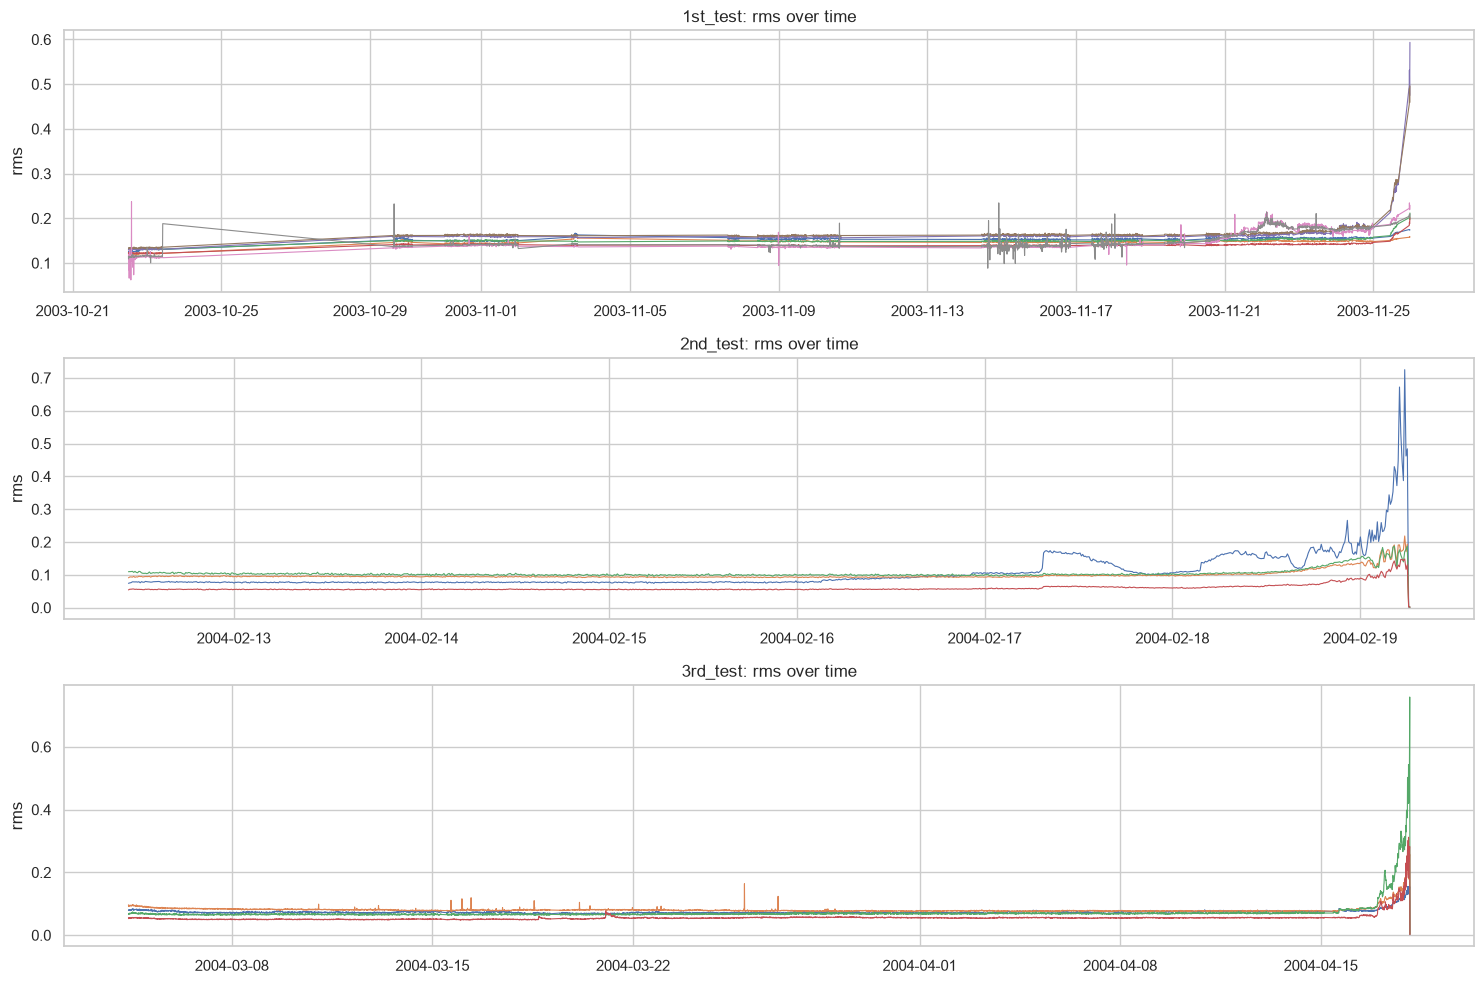

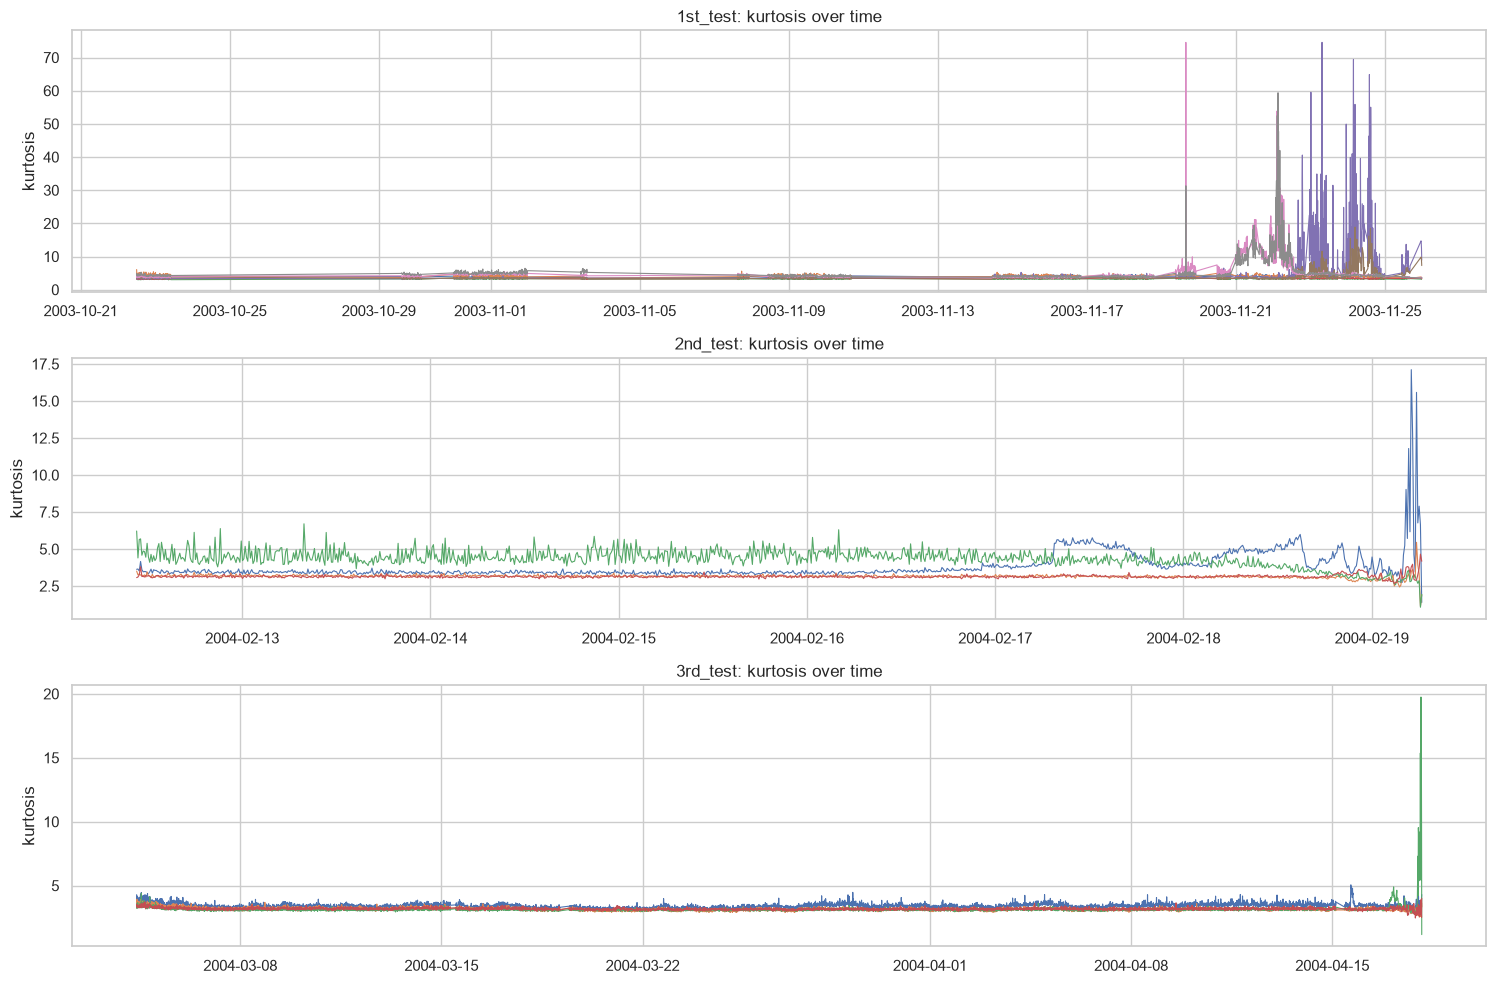

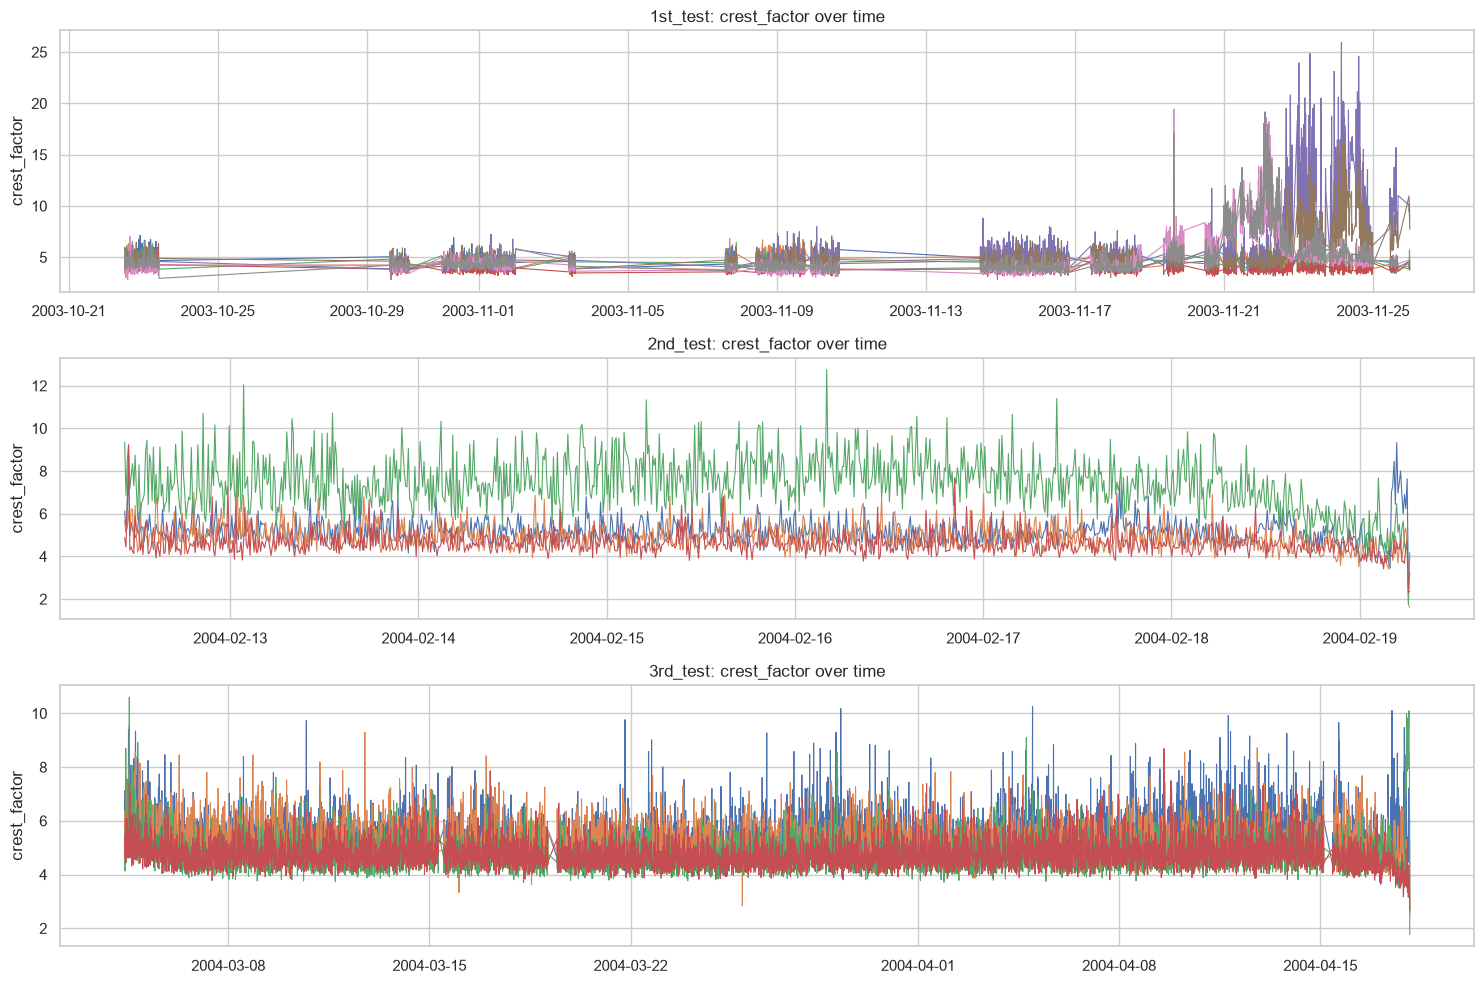

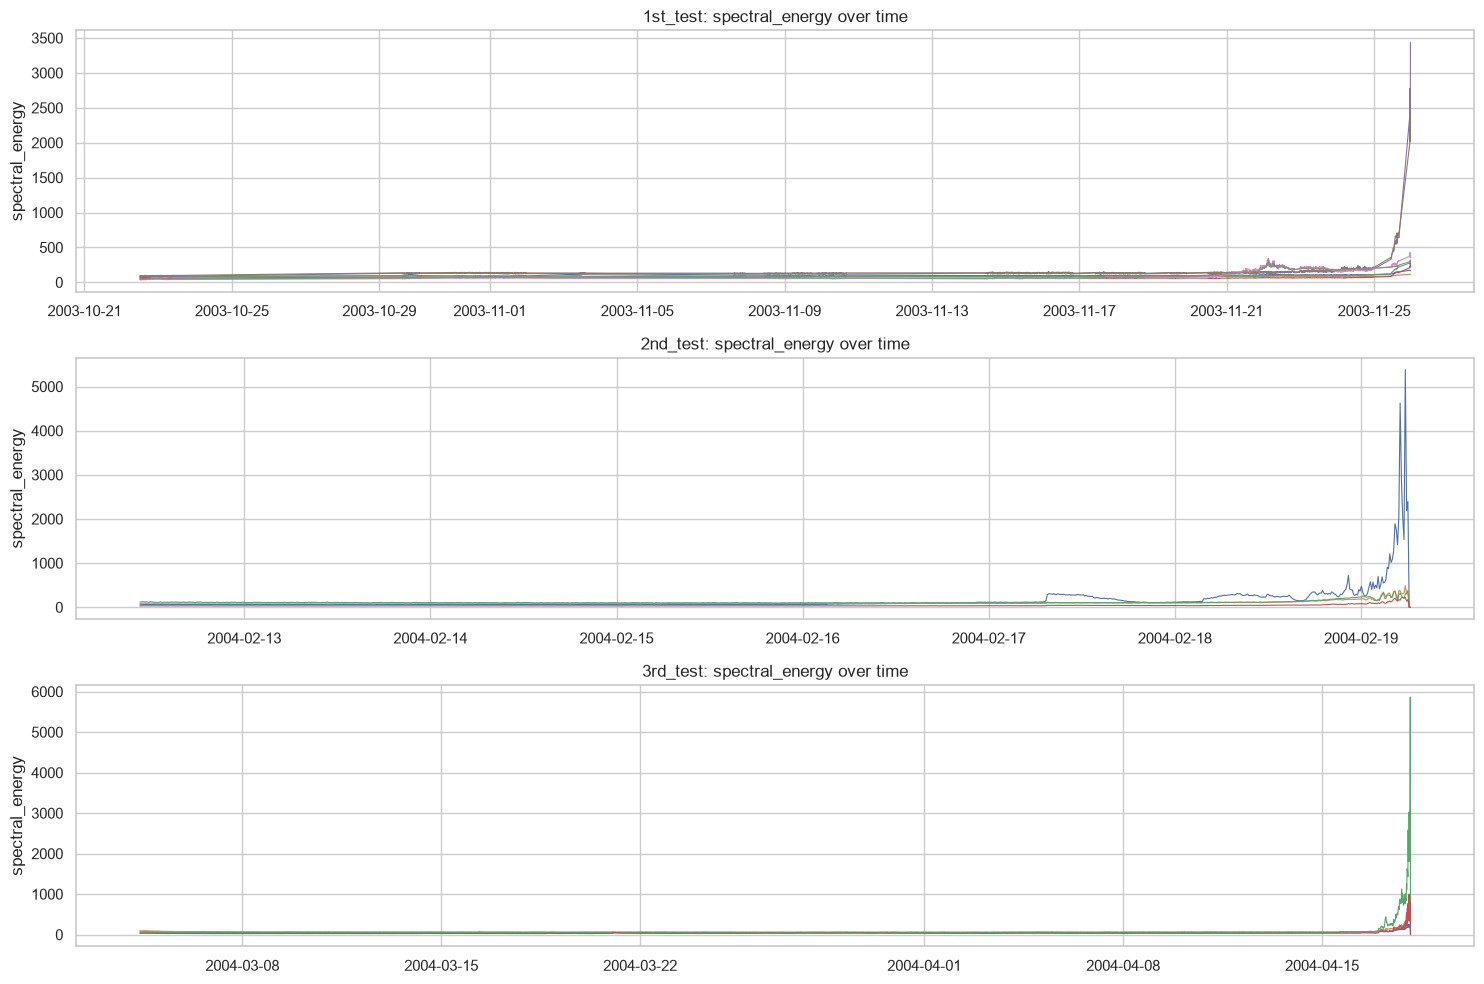

[WindowsPath('C:/Users/Balsem/Desktop/GMAO/ai-service/artifacts/plots/ims_rms_over_time.png'),
 WindowsPath('C:/Users/Balsem/Desktop/GMAO/ai-service/artifacts/plots/ims_kurtosis_over_time.png'),
 WindowsPath('C:/Users/Balsem/Desktop/GMAO/ai-service/artifacts/plots/ims_crest_factor_over_time.png'),
 WindowsPath('C:/Users/Balsem/Desktop/GMAO/ai-service/artifacts/plots/ims_spectral_energy_over_time.png')]

In [3]:
def plot_metric_over_time(metric: str) -> Path:
    figure, axes = plt.subplots(len(feature_inventory), 1, figsize=(15, 10), sharex=False)
    if len(feature_inventory) == 1:
        axes = [axes]
    for axis, experiment in zip(axes, feature_inventory["experiment"]):
        subset = features[features["experiment"].eq(experiment)]
        sns.lineplot(
            data=subset,
            x="timestamp",
            y=metric,
            hue="channel_label",
            linewidth=0.8,
            ax=axis,
            legend=False,
        )
        axis.set_title(f"{experiment}: {metric} over time")
        axis.set_xlabel("")
        axis.set_ylabel(metric)
    figure.tight_layout()
    output = PLOTS_DIR / f"ims_{metric}_over_time.png"
    figure.savefig(output, dpi=160, bbox_inches="tight")
    plt.show()
    return output


plot_paths = [plot_metric_over_time(metric) for metric in METRICS]
plot_paths

## 3. Chronological Baseline Split

In [4]:
def add_time_index(frame: pd.DataFrame) -> pd.DataFrame:
    indexed = frame.copy()
    unique_timestamps = indexed[["timestamp"]].drop_duplicates().sort_values("timestamp").reset_index(drop=True)
    unique_timestamps["time_index"] = np.arange(len(unique_timestamps))
    indexed = indexed.merge(unique_timestamps, on="timestamp", how="left")
    denominator = max(int(unique_timestamps["time_index"].max()), 1)
    indexed["life_fraction"] = indexed["time_index"] / denominator
    return indexed


baseline_data = add_time_index(features[features["experiment"].eq(BASELINE_EXPERIMENT)].copy())
healthy = baseline_data[baseline_data["life_fraction"].le(HEALTHY_FRACTION)].copy()
evaluation = baseline_data[baseline_data["life_fraction"].ge(EVALUATION_START_FRACTION)].copy()

split_summary = pd.DataFrame(
    [
        {
            "baseline_experiment": BASELINE_EXPERIMENT,
            "healthy_fraction": HEALTHY_FRACTION,
            "evaluation_start_fraction": EVALUATION_START_FRACTION,
            "healthy_rows": len(healthy),
            "healthy_timestamps": healthy["timestamp"].nunique(),
            "evaluation_rows": len(evaluation),
            "evaluation_timestamps": evaluation["timestamp"].nunique(),
            "healthy_first_timestamp": healthy["timestamp"].min(),
            "healthy_last_timestamp": healthy["timestamp"].max(),
            "evaluation_first_timestamp": evaluation["timestamp"].min(),
            "evaluation_last_timestamp": evaluation["timestamp"].max(),
        }
    ]
)

split_summary

,baseline_experiment,healthy_fraction,evaluation_start_fraction,healthy_rows,healthy_timestamps,evaluation_rows,evaluation_timestamps,healthy_first_timestamp,healthy_last_timestamp,evaluation_first_timestamp,evaluation_last_timestamp
0,1st_test,0.2,0.5,3456,432,8624,1078,2003-10-22 12:06:24,2003-11-01 10:31:44,2003-11-15 18:18:46,2003-11-25 23:39:56


## 4. Dynamic Rolling Z-Score Baseline

In [5]:
def dynamic_z_scores(frame: pd.DataFrame, healthy_frame: pd.DataFrame) -> pd.DataFrame:
    output = frame.sort_values(["sensor_channel", "timestamp"]).copy()
    scored_groups = []
    epsilon = 1e-12
    for channel, channel_frame in output.groupby("sensor_channel", sort=True):
        channel_frame = channel_frame.sort_values("timestamp").copy()
        healthy_channel = healthy_frame[healthy_frame["sensor_channel"].eq(channel)].sort_values("timestamp")
        baseline_tail = healthy_channel[MODEL_FEATURES].tail(max(ROLLING_WINDOW, 1))
        history = pd.concat([baseline_tail, channel_frame[MODEL_FEATURES]], ignore_index=True)
        rolling_mean = history.rolling(ROLLING_WINDOW, min_periods=max(5, min(ROLLING_WINDOW, len(baseline_tail)))).mean().shift(1)
        rolling_std = history.rolling(ROLLING_WINDOW, min_periods=max(5, min(ROLLING_WINDOW, len(baseline_tail)))).std(ddof=1).shift(1)
        baseline_std = healthy_channel[MODEL_FEATURES].std(ddof=1).replace(0, np.nan).fillna(epsilon)
        std_floor = baseline_std.clip(lower=epsilon) * 0.05
        rolling_std = rolling_std.clip(lower=std_floor, axis=1)
        scored_metrics = (history[MODEL_FEATURES] - rolling_mean) / rolling_std
        scored_metrics = scored_metrics.iloc[len(baseline_tail):].reset_index(drop=True).fillna(0)
        for metric in MODEL_FEATURES:
            channel_frame[f"z_{metric}"] = scored_metrics[metric].to_numpy()
        z_columns = [f"z_{metric}" for metric in MODEL_FEATURES]
        channel_frame["z_anomaly_score"] = np.sqrt(np.mean(np.square(channel_frame[z_columns]), axis=1))
        scored_groups.append(channel_frame)
    return pd.concat(scored_groups, ignore_index=True).sort_values(["timestamp", "sensor_channel"])


z_evaluation = dynamic_z_scores(evaluation, healthy)
z_threshold = float(z_evaluation["z_anomaly_score"].quantile(ANOMALY_QUANTILE))
z_evaluation["z_is_anomaly"] = z_evaluation["z_anomaly_score"].ge(z_threshold)

z_evaluation[["timestamp", "sensor_channel", "bearing", "z_anomaly_score", "z_is_anomaly"]].head()

,timestamp,sensor_channel,bearing,z_anomaly_score,z_is_anomaly
0,2003-11-15 18:18:46,1,1,3.021896,False
1078,2003-11-15 18:18:46,2,1,2.503493,False
2156,2003-11-15 18:18:46,3,2,1.465875,False
3234,2003-11-15 18:18:46,4,2,3.494460,False
4312,2003-11-15 18:18:46,5,3,1.860452,False


## 5. Isolation Forest Baseline

In [6]:
isolation_forest = Pipeline(
    steps=[
        ("scaler", StandardScaler()),
        (
            "model",
            IsolationForest(
                n_estimators=200,
                contamination="auto",
                random_state=42,
                n_jobs=-1,
            ),
        ),
    ]
)

isolation_forest.fit(healthy[MODEL_FEATURES])
if_scores = -isolation_forest.decision_function(evaluation[MODEL_FEATURES])
if_threshold = float(np.quantile(if_scores, ANOMALY_QUANTILE))

if_evaluation = evaluation.copy()
if_evaluation["if_anomaly_score"] = if_scores
if_evaluation["if_is_anomaly"] = if_evaluation["if_anomaly_score"].ge(if_threshold)

joblib.dump(isolation_forest, MODELS_DIR / "ims_isolation_forest_baseline.joblib")
if_evaluation[["timestamp", "sensor_channel", "bearing", "if_anomaly_score", "if_is_anomaly"]].head()

,timestamp,sensor_channel,bearing,if_anomaly_score,if_is_anomaly
8624,2003-11-15 18:18:46,1,1,-0.053042,False
8625,2003-11-15 18:18:46,2,1,-0.087839,False
8626,2003-11-15 18:18:46,3,2,-0.093031,False
8627,2003-11-15 18:18:46,4,2,-0.047527,False
8628,2003-11-15 18:18:46,5,3,0.013762,False


## 6. Compare Baselines

In [7]:
comparison = z_evaluation[["timestamp", "experiment", "sensor_channel", "bearing", "axis", "channel_label", "life_fraction", "z_anomaly_score", "z_is_anomaly"]].merge(
    if_evaluation[["timestamp", "sensor_channel", "if_anomaly_score", "if_is_anomaly"]],
    on=["timestamp", "sensor_channel"],
    how="inner",
)
comparison["both_anomaly"] = comparison["z_is_anomaly"] & comparison["if_is_anomaly"]

comparison_summary = pd.DataFrame(
    [
        {
            "evaluation_rows": len(comparison),
            "evaluation_timestamps": comparison["timestamp"].nunique(),
            "z_threshold": z_threshold,
            "z_anomalies": int(comparison["z_is_anomaly"].sum()),
            "if_threshold": if_threshold,
            "if_anomalies": int(comparison["if_is_anomaly"].sum()),
            "overlap_anomalies": int(comparison["both_anomaly"].sum()),
        }
    ]
)

comparison_summary

,evaluation_rows,evaluation_timestamps,z_threshold,z_anomalies,if_threshold,if_anomalies,overlap_anomalies
0,8624,1078,4.130459,44,0.229977,45,3


In [8]:
comparison_by_bearing = comparison.groupby("bearing").agg(
    rows=("timestamp", "size"),
    z_mean_score=("z_anomaly_score", "mean"),
    z_max_score=("z_anomaly_score", "max"),
    z_anomalies=("z_is_anomaly", "sum"),
    if_mean_score=("if_anomaly_score", "mean"),
    if_max_score=("if_anomaly_score", "max"),
    if_anomalies=("if_is_anomaly", "sum"),
    overlap_anomalies=("both_anomaly", "sum"),
).reset_index()

comparison_by_bearing

,bearing,rows,z_mean_score,z_max_score,z_anomalies,if_mean_score,if_max_score,if_anomalies,overlap_anomalies
0,1,2156,1.039832,8.058003,3,-0.036960,0.124373,0,0
1,2,2156,2.783745,2114.640187,3,-0.067994,0.114310,0,0
2,3,2156,1.804113,1231.410940,16,0.100615,0.250329,45,3
3,4,2156,6.810115,4483.107373,22,0.074612,0.227661,0,0


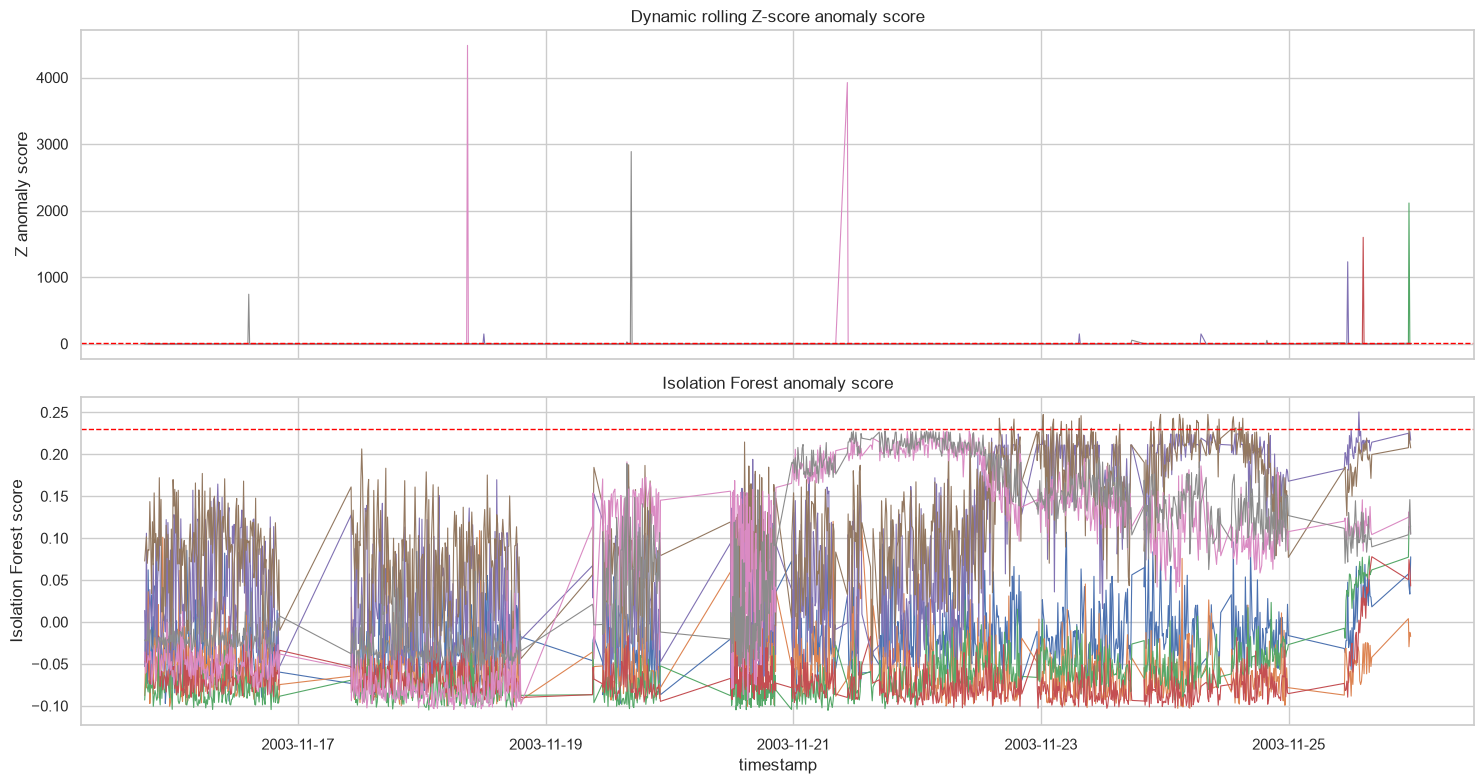

WindowsPath('C:/Users/Balsem/Desktop/GMAO/ai-service/artifacts/plots/ims_anomaly_score_comparison.png')

In [9]:
figure, axes = plt.subplots(2, 1, figsize=(15, 8), sharex=True)
sns.lineplot(data=comparison, x="timestamp", y="z_anomaly_score", hue="channel_label", linewidth=0.8, legend=False, ax=axes[0])
axes[0].axhline(z_threshold, color="red", linestyle="--", linewidth=1, label="threshold")
axes[0].set_title("Dynamic rolling Z-score anomaly score")
axes[0].set_ylabel("Z anomaly score")

sns.lineplot(data=comparison, x="timestamp", y="if_anomaly_score", hue="channel_label", linewidth=0.8, legend=False, ax=axes[1])
axes[1].axhline(if_threshold, color="red", linestyle="--", linewidth=1, label="threshold")
axes[1].set_title("Isolation Forest anomaly score")
axes[1].set_ylabel("Isolation Forest score")

figure.tight_layout()
comparison_plot_path = PLOTS_DIR / "ims_anomaly_score_comparison.png"
figure.savefig(comparison_plot_path, dpi=160, bbox_inches="tight")
plt.show()

comparison_plot_path

## 7. Save Comparison Outputs

In [10]:
comparison_output_path = PROJECT_ROOT / "data" / "processed" / "ims_anomaly_baseline_scores.csv"
comparison.to_csv(comparison_output_path, index=False)

saved_outputs = pd.DataFrame(
    [
        {"artifact": "baseline scores", "path": comparison_output_path.as_posix(), "rows": len(comparison)},
        {"artifact": "isolation forest model", "path": (MODELS_DIR / "ims_isolation_forest_baseline.joblib").as_posix(), "rows": None},
        {"artifact": "anomaly comparison plot", "path": comparison_plot_path.as_posix(), "rows": None},
        *({"artifact": f"{metric} degradation plot", "path": path.as_posix(), "rows": None} for metric, path in zip(METRICS, plot_paths)),
    ]
)

saved_outputs

,artifact,path,rows
0,baseline scores,C:/Users/Balsem/Desktop/GMAO/ai-service/data/p...,8624.0
1,isolation forest model,C:/Users/Balsem/Desktop/GMAO/ai-service/artifa...,NaN
2,anomaly comparison plot,C:/Users/Balsem/Desktop/GMAO/ai-service/artifa...,NaN
3,rms degradation plot,C:/Users/Balsem/Desktop/GMAO/ai-service/artifa...,NaN
4,kurtosis degradation plot,C:/Users/Balsem/Desktop/GMAO/ai-service/artifa...,NaN
5,crest_factor degradation plot,C:/Users/Balsem/Desktop/GMAO/ai-service/artifa...,NaN
6,spectral_energy degradation plot,C:/Users/Balsem/Desktop/GMAO/ai-service/artifa...,NaN
